# CollegeMsg

https://snap.stanford.edu/data/CollegeMsg.html

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./data/CollegeMsg.txt', names=["src", "dst", "unix_ts"], sep=" ")

In [3]:
df.head()

,src,dst,unix_ts
0,1,2,1082040961
1,3,4,1082155839
2,5,2,1082414391
3,6,7,1082439619
4,8,7,1082439756


In [4]:
df.shape

(59835, 3)

### Convert timestamps

In [5]:
df["datetime"] = pd.to_datetime(df["unix_ts"], unit="s")
print(df[["src", "dst", "datetime"]].head())

   src  dst            datetime
0    1    2 2004-04-15 14:56:01
1    3    4 2004-04-16 22:50:39
2    5    2 2004-04-19 22:39:51
3    6    7 2004-04-20 05:40:19
4    8    7 2004-04-20 05:42:36


### Basic inspection

In [6]:
print("Number of messages:", len(df))
print("Unique senders/receivers:", len(set(df["src"]).union(df["dst"])))
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())

Number of messages: 59835
Unique senders/receivers: 1899
Date range: 2004-04-15 14:56:01 to 2004-10-26 07:52:22


### Messages per day

In [7]:
daily_counts = (
    df.set_index("datetime")
      .resample("D")
      .size()
      .rename("num_messages")
)

print(daily_counts.head())

datetime
2004-04-15    1
2004-04-16    1
2004-04-17    0
2004-04-18    0
2004-04-19    1
Freq: D, Name: num_messages, dtype: int64


### Plot

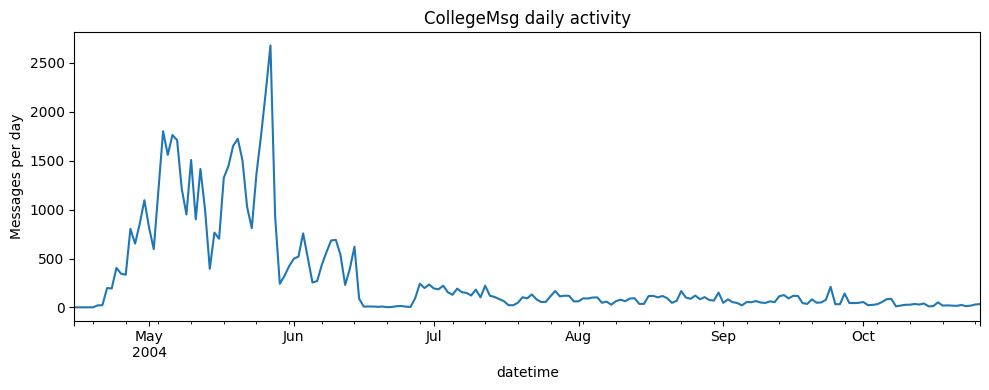

In [8]:
import matplotlib.pyplot as plt

daily_counts.plot(figsize=(10, 4))
plt.ylabel("Messages per day")
plt.title("CollegeMsg daily activity")
plt.tight_layout()
plt.show()

### Static Directed Graph

In [9]:
import networkx as nx

edge_weights = (
    df.groupby(["src", "dst"])
      .size()
      .reset_index(name="weight")
)

G = nx.DiGraph()
for row in edge_weights.itertuples(index=False):
    G.add_edge(row.src, row.dst, weight=row.weight)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1899
Edges: 20296


### Graph Stats

In [10]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

top_out = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
top_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top senders:", top_out)
print("Top receivers:", top_in)

Top senders: [(9, 237), (103, 233), (105, 219), (400, 217), (32, 182), (41, 178), (3, 175), (249, 168), (42, 160), (713, 148)]
Top receivers: [(32, 137), (42, 120), (638, 119), (372, 115), (598, 115), (103, 106), (194, 97), (249, 97), (1283, 96), (713, 95)]


### Aggregate

weekly activity

In [11]:
weekly_counts = (
    df.set_index("datetime")
      .resample("W")
      .size()
      .rename("num_messages")
)

print(weekly_counts.head())

datetime
2004-04-18        2
2004-04-25     1185
2004-05-02     5152
2004-05-09    10194
2004-05-16     6679
Freq: W-SUN, Name: num_messages, dtype: int64


Hour-of-day pattern:

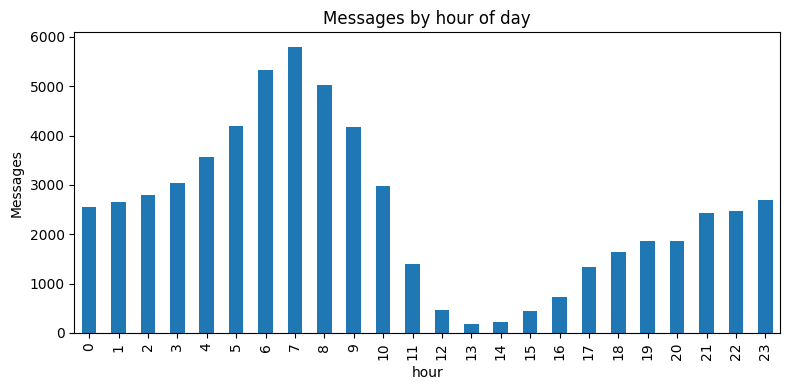

In [12]:
df["hour"] = df["datetime"].dt.hour
hour_counts = df.groupby("hour").size()

hour_counts.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Messages")
plt.title("Messages by hour of day")
plt.tight_layout()
plt.show()

### temporal snapshots

In [13]:
df = df.sort_values("datetime")

# Example: one graph per week
weekly_graphs = {}

for week_start, group in df.groupby(pd.Grouper(key="datetime", freq="W")):
    edges = (
        group.groupby(["src", "dst"])
             .size()
             .reset_index(name="weight")
    )
    G_week = nx.DiGraph()
    for row in edges.itertuples(index=False):
        G_week.add_edge(row.src, row.dst, weight=row.weight)
    weekly_graphs[week_start] = G_week

print("Number of weekly snapshots:", len(weekly_graphs))

Number of weekly snapshots: 29
